# 1. Setup and Forecast Design

In [2]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [3]:
current_dir = Path.cwd().resolve()
project_name = 'ride-hailing-demand-fleet-allocation'

if current_dir.name == project_name:
    project_root = current_dir
elif current_dir.name == 'notebooks' and current_dir.parent.name == project_name:
    project_root = current_dir.parent
else:
    project_root = current_dir / project_name

if not project_root.exists():
    raise FileNotFoundError(
        f'Project folder not found: {project_root}'
    )

database_path = project_root / 'data' / 'processed' / 'nyc_taxi.db'

print(f'Current directory: {current_dir}')
print(f'Project root     : {project_root}')
print(f'Database path    : {database_path}')

Current directory: D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation\notebooks
Project root     : D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation
Database path    : D:\My Journey\Data Project\ride-hailing-demand-fleet-allocation\data\processed\nyc_taxi.db


In [4]:
if not database_path.exists():
    raise FileNotFoundError(
        f'Database not found: {database_path}'
    )

con = duckdb.connect(str(database_path), read_only=True)

In [5]:
fact_trip_rows = con.execute("""
    SELECT COUNT(*)
    FROM fact_trip
""").fetchone()[0]

actionable_zones = con.execute("""
    SELECT COUNT(*)
    FROM dim_zone
    WHERE LocationID NOT IN (264, 265)
      AND Borough <> 'EWR'
""").fetchone()[0]

time_rows = con.execute("""
    SELECT COUNT(*)
    FROM dim_time
""").fetchone()[0]

print(f'Fact trip rows  : {fact_trip_rows:,}')
print(f'Actionable zones: {actionable_zones:,}')
print(f'Hourly time rows: {time_rows:,}')

Fact trip rows  : 239,426,737
Actionable zones: 262
Hourly time rows: 8,784


# 2. Build Hourly Demand Dataset

In [9]:
df_hourly_demand = con.execute("""
    WITH hourly_trips AS (
        SELECT
            trip.time_id,
            trip.PULocationID AS LocationID,
            COUNT(*) AS completed_trips
        FROM fact_trip AS trip
        JOIN dim_zone AS zone
            ON trip.PULocationID = zone.LocationID
        WHERE zone.LocationID NOT IN (264, 265)
          AND zone.Borough <> 'EWR'
        GROUP BY
            trip.time_id,
            trip.PULocationID
    )

    SELECT
        time.time_id,
        CAST(time.time_id AS DATE) AS demand_date,
        zone.LocationID,
        zone.Zone AS pickup_zone,
        zone.Borough AS pickup_borough,
        EXTRACT(HOUR FROM time.time_id) AS hour_of_day,
        ISODOW(time.time_id) AS day_of_week,
        EXTRACT(MONTH FROM time.time_id) AS month,
        CASE
            WHEN ISODOW(time.time_id) IN (6, 7) THEN 1
            ELSE 0
        END AS is_weekend,
        COALESCE(trip.completed_trips, 0) AS completed_trips
    FROM dim_time AS time
    CROSS JOIN dim_zone AS zone
    LEFT JOIN hourly_trips AS trip
        ON time.time_id = trip.time_id
        AND zone.LocationID = trip.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
      AND zone.Borough <> 'EWR'
    ORDER BY
        time.time_id,
        zone.LocationID
""").df()

df_hourly_demand.head()

,time_id,demand_date,LocationID,pickup_zone,pickup_borough,hour_of_day,day_of_week,month,is_weekend,completed_trips
0,2024-01-01,2024-01-01,2,Jamaica Bay,Queens,0,1,1,0,0
1,2024-01-01,2024-01-01,3,Allerton/Pelham Gardens,Bronx,0,1,1,0,75
2,2024-01-01,2024-01-01,4,Alphabet City,Manhattan,0,1,1,0,266
3,2024-01-01,2024-01-01,5,Arden Heights,Staten Island,0,1,1,0,19
4,2024-01-01,2024-01-01,6,Arrochar/Fort Wadsworth,Staten Island,0,1,1,0,32


In [10]:
df_hourly_demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 2301408 entries, 0 to 2301407
Data columns (total 10 columns):
 #   Column           Dtype         
---  ------           -----         
 0   time_id          datetime64[us]
 1   demand_date      datetime64[us]
 2   LocationID       int64         
 3   pickup_zone      str           
 4   pickup_borough   str           
 5   hour_of_day      int64         
 6   day_of_week      int64         
 7   month            int64         
 8   is_weekend       int32         
 9   completed_trips  int64         
dtypes: datetime64[us](2), int32(1), int64(5), str(2)
memory usage: 166.8 MB


In [16]:
df_hourly_demand['LocationID'] = df_hourly_demand['LocationID'].astype('int16')
df_hourly_demand['hour_of_day'] = df_hourly_demand['hour_of_day'].astype('int8')
df_hourly_demand['day_of_week'] = df_hourly_demand['day_of_week'].astype('int8')
df_hourly_demand['month'] = df_hourly_demand['month'].astype('int8')
df_hourly_demand['is_weekend'] = df_hourly_demand['is_weekend'].astype('int8')
df_hourly_demand['completed_trips'] = df_hourly_demand['completed_trips'].astype('int32')
df_hourly_demand[['pickup_zone', 'pickup_borough']] = df_hourly_demand[['pickup_zone', 'pickup_borough']].astype('category')

In [17]:
memory_mb = df_hourly_demand.memory_usage(
    deep=True
).sum() / 1024**2

print(f'Dataset memory: {memory_mb:,.2f} MB')

Dataset memory: 63.67 MB


In [13]:
expected_rows = time_rows * actionable_zones
actual_rows = len(df_hourly_demand)

print(f'Expected rows : {expected_rows:,}')
print(f'Actual rows   : {actual_rows:,}')
print(f'Unique hours  : {df_hourly_demand["time_id"].nunique():,}')
print(f'Unique zones  : {df_hourly_demand["LocationID"].nunique():,}')
print(f'Zero rows     : {(df_hourly_demand["completed_trips"] == 0).sum():,}')
print(f'Missing values: {df_hourly_demand["completed_trips"].isna().sum():,}')

Expected rows : 2,301,408
Actual rows   : 2,301,408
Unique hours  : 8,784
Unique zones  : 262
Zero rows     : 91,481
Missing values: 0


In [18]:
expected_trip_total = con.execute("""
    SELECT COUNT(*)
    FROM fact_trip AS trip
    JOIN dim_zone AS zone
        ON trip.PULocationID = zone.LocationID
    WHERE zone.LocationID NOT IN (264, 265)
      AND zone.Borough <> 'EWR'
""").fetchone()[0]

hourly_trip_total = df_hourly_demand[
    'completed_trips'
].sum()

print(f'Expected trip total: {expected_trip_total:,}')
print(f'Hourly trip total  : {hourly_trip_total:,}')
print(f'Totals match       : {expected_trip_total == hourly_trip_total}')

Expected trip total: 239,417,292
Hourly trip total  : 239,417,292
Totals match       : True


# 3. Create Time-Based Data Split

In [19]:
validation_start = pd.Timestamp('2024-11-01')
test_start = pd.Timestamp('2024-12-01')
test_end = pd.Timestamp('2025-01-01')

print(f'Validation starts: {validation_start.date()}')
print(f'Test starts      : {test_start.date()}')
print(f'Test ends        : {test_end.date()}')

Validation starts: 2024-11-01
Test starts      : 2024-12-01
Test ends        : 2025-01-01


In [20]:
df_train = df_hourly_demand[
    df_hourly_demand['time_id'] < validation_start
].copy()

df_validation = df_hourly_demand[
    (df_hourly_demand['time_id'] >= validation_start)
    & (df_hourly_demand['time_id'] < test_start)
].copy()

df_test = df_hourly_demand[
    (df_hourly_demand['time_id'] >= test_start)
    & (df_hourly_demand['time_id'] < test_end)
].copy()

In [21]:
print(f'Train rows     : {len(df_train):,}')
print(f'Validation rows: {len(df_validation):,}')
print(f'Test rows      : {len(df_test):,}')

print(
    f'\nTrain range     : '
    f'{df_train["time_id"].min()} to '
    f'{df_train["time_id"].max()}'
)

print(
    f'Validation range: '
    f'{df_validation["time_id"].min()} to '
    f'{df_validation["time_id"].max()}'
)

print(
    f'Test range      : '
    f'{df_test["time_id"].min()} to '
    f'{df_test["time_id"].max()}'
)

Train rows     : 1,917,840
Validation rows: 188,640
Test rows      : 194,928

Train range     : 2024-01-01 00:00:00 to 2024-10-31 23:00:00
Validation range: 2024-11-01 00:00:00 to 2024-11-30 23:00:00
Test range      : 2024-12-01 00:00:00 to 2024-12-31 23:00:00


In [22]:
df_split_summary = pd.DataFrame({
    'split': ['Train', 'Validation', 'Test'],
    'number_of_rows': [
        len(df_train),
        len(df_validation),
        len(df_test)
    ],
    'total_completed_trips': [
        df_train['completed_trips'].sum(),
        df_validation['completed_trips'].sum(),
        df_test['completed_trips'].sum()
    ],
    'avg_trips_per_zone_hour': [
        df_train['completed_trips'].mean(),
        df_validation['completed_trips'].mean(),
        df_test['completed_trips'].mean()
    ],
    'zero_demand_pct': [
        (df_train['completed_trips'] == 0).mean() * 100,
        (df_validation['completed_trips'] == 0).mean() * 100,
        (df_test['completed_trips'] == 0).mean() * 100
    ]
})

df_split_summary.round(2)

,split,number_of_rows,total_completed_trips,avg_trips_per_zone_hour,zero_demand_pct
0,Train,1917840,198378204,103.44,3.95
1,Validation,188640,19974210,105.89,4.04
2,Test,194928,21064878,108.06,4.13


# 4. Build Historical Baseline

In [56]:
df_baseline_lookup = (
    df_train
    .groupby(['LocationID', 'hour_of_day', 'day_of_week'], as_index=False)
    .agg(baseline_prediction=('completed_trips', 'mean'))
)

expected_lookup_rows = actionable_zones * 24 * 7

display(df_baseline_lookup.head())
print(f'Expected lookup rows: {expected_lookup_rows:,}')
print(f'Actual lookup rows  : {len(df_baseline_lookup):,}')

,LocationID,hour_of_day,day_of_week,baseline_prediction
0,2,0,1,0.0
1,2,0,2,0.0
2,2,0,3,0.0
3,2,0,4,0.0
4,2,0,5,0.0


Expected lookup rows: 44,016
Actual lookup rows  : 44,016


In [57]:
df_validation_baseline = df_validation.merge(
    df_baseline_lookup,
    on=['LocationID', 'hour_of_day', 'day_of_week'],
    how='left'
)

print(f'Validation rows       : {len(df_validation_baseline):,}')
print(f'Missing predictions   : {df_validation_baseline["baseline_prediction"].isna().sum():,}')
print(f'Negative predictions  : {(df_validation_baseline["baseline_prediction"] < 0).sum():,}')
print(f'Average actual demand : {df_validation_baseline["completed_trips"].mean():,.2f}')
print(f'Average prediction    : {df_validation_baseline["baseline_prediction"].mean():,.2f}')

Validation rows       : 188,640
Missing predictions   : 0
Negative predictions  : 0
Average actual demand : 105.89
Average prediction    : 104.49


# 5. Prepare Modeling Features

In [59]:
df_zone_avg = (
    df_train.groupby('LocationID', as_index=False)
    .agg(zone_avg_trips=('completed_trips', 'mean'))
)

df_zone_hour_avg = (
    df_train.groupby(['LocationID', 'hour_of_day'], as_index=False)
    .agg(zone_hour_avg_trips=('completed_trips', 'mean'))
)

df_zone_day_avg = (
    df_train.groupby(['LocationID', 'day_of_week'], as_index=False)
    .agg(zone_day_avg_trips=('completed_trips', 'mean'))
)

print(f'Zone lookup     : {len(df_zone_avg):,}')
print(f'Zone-hour lookup: {len(df_zone_hour_avg):,}')
print(f'Zone-day lookup : {len(df_zone_day_avg):,}')

Zone lookup     : 262
Zone-hour lookup: 6,288
Zone-day lookup : 1,834


In [60]:
base_columns = [
    'time_id', 'LocationID', 'hour_of_day', 'day_of_week',
    'month', 'is_weekend', 'completed_trips'
]

df_feature_data = pd.concat(
    [df_train[base_columns], df_validation[base_columns]],
    ignore_index=True
)

df_feature_data = (
    df_feature_data
    .merge(df_zone_avg, on='LocationID', how='left')
    .merge(df_zone_hour_avg, on=['LocationID', 'hour_of_day'], how='left')
    .merge(df_zone_day_avg, on=['LocationID', 'day_of_week'], how='left')
    .merge(df_baseline_lookup, on=['LocationID', 'hour_of_day', 'day_of_week'], how='left')
)

df_feature_data['days_since_start'] = (
    df_feature_data['time_id'] - pd.Timestamp('2024-01-01')
).dt.days.astype('int16')

df_train_features = df_feature_data[df_feature_data['time_id'] < validation_start].copy()
df_validation_features = df_feature_data[df_feature_data['time_id'] >= validation_start].copy()

del df_feature_data

In [62]:
feature_columns = [
    'zone_avg_trips',
    'zone_hour_avg_trips',
    'zone_day_avg_trips',
    'baseline_prediction',
    'hour_of_day',
    'day_of_week',
    'month',
    'is_weekend',
    'days_since_start'
]

target_column = 'completed_trips'

train_missing = df_train_features[feature_columns].isna().sum().sum()
validation_missing = df_validation_features[feature_columns].isna().sum().sum()

print(f'Train feature rows     : {len(df_train_features):,}')
print(f'Validation feature rows: {len(df_validation_features):,}')
print(f'Train missing values   : {train_missing:,}')
print(f'Validation missing     : {validation_missing:,}')

Train feature rows     : 1,917,840
Validation feature rows: 188,640
Train missing values   : 0
Validation missing     : 0


# 6. Train Candidate Models

In [63]:
X_train = df_train_features[feature_columns].astype('float32')
y_train = df_train_features[target_column].astype('float32')

X_validation = df_validation_features[feature_columns].astype('float32')
y_validation = df_validation_features[target_column].astype('float32')

print(f'Train      : X {X_train.shape}, y {y_train.shape}')
print(f'Validation : X {X_validation.shape}, y {y_validation.shape}')

Train      : X (1917840, 9), y (1917840,)
Validation : X (188640, 9), y (188640,)


In [64]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_prediction_raw = linear_model.predict(X_validation)
negative_linear_predictions = (linear_prediction_raw < 0).sum()
linear_validation_prediction = np.clip(linear_prediction_raw, 0, None)

print(f'Negative predictions before clipping: {negative_linear_predictions:,}')

Negative predictions before clipping: 15,698


In [65]:
boosting_model = HistGradientBoostingRegressor(
    loss='poisson',
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

boosting_model.fit(X_train, y_train)
boosting_validation_prediction = np.clip(boosting_model.predict(X_validation), 0, None)

In [66]:
df_validation_predictions = df_validation_features[
    ['time_id', 'LocationID', 'completed_trips', 'baseline_prediction']
].copy()

df_validation_predictions['linear_prediction'] = linear_validation_prediction
df_validation_predictions['boosting_prediction'] = boosting_validation_prediction

prediction_columns = [
    'baseline_prediction',
    'linear_prediction',
    'boosting_prediction'
]

missing_predictions = df_validation_predictions[prediction_columns].isna().sum().sum()
negative_predictions = (df_validation_predictions[prediction_columns] < 0).sum().sum()

models_passed = (
    len(df_validation_predictions) == len(df_validation)
    and missing_predictions == 0
    and negative_predictions == 0
)

print(f'Prediction rows     : {len(df_validation_predictions):,}')
print(f'Missing predictions : {missing_predictions:,}')
print(f'Negative predictions: {negative_predictions:,}')

Prediction rows     : 188,640
Missing predictions : 0
Negative predictions: 0


# 7. Evaluate and Select Model

## a. Validation model comparison

In [77]:
def calculate_wape(actual, prediction):
    return np.abs(actual - prediction).sum() / actual.sum() * 100

def calculate_mape_nonzero(actual, prediction):
    mask = actual > 0
    return np.abs((actual[mask] - prediction[mask]) / actual[mask]).mean() * 100

def calculate_bias(actual, prediction):
    return (prediction - actual).sum() / actual.sum() * 100

In [78]:
model_predictions = {
    'Historical Baseline': 'baseline_prediction',
    'Linear Regression': 'linear_prediction',
    'HistGradientBoosting': 'boosting_prediction'
}

actual_validation = df_validation_predictions['completed_trips'].to_numpy()
evaluation_rows = []

for model_name, prediction_column in model_predictions.items():
    prediction = df_validation_predictions[prediction_column].to_numpy()

    evaluation_rows.append({
        'model': model_name,
        'WAPE (%)': calculate_wape(actual_validation, prediction),
        'MAE': mean_absolute_error(actual_validation, prediction),
        'MAPE nonzero (%)': calculate_mape_nonzero(actual_validation, prediction),
        'Bias (%)': calculate_bias(actual_validation, prediction)
    })

df_validation_evaluation = (
    pd.DataFrame(evaluation_rows)
    .sort_values('WAPE (%)')
    .reset_index(drop=True)
)

df_validation_evaluation.round(2)

,model,WAPE (%),MAE,MAPE nonzero (%),Bias (%)
0,Historical Baseline,15.40,16.31,24.09,-1.32
1,HistGradientBoosting,16.89,17.89,27.90,5.15
2,Linear Regression,18.62,19.71,28.63,-4.22


Selected model : Historical Baseline
Validation WAPE: 15.40%


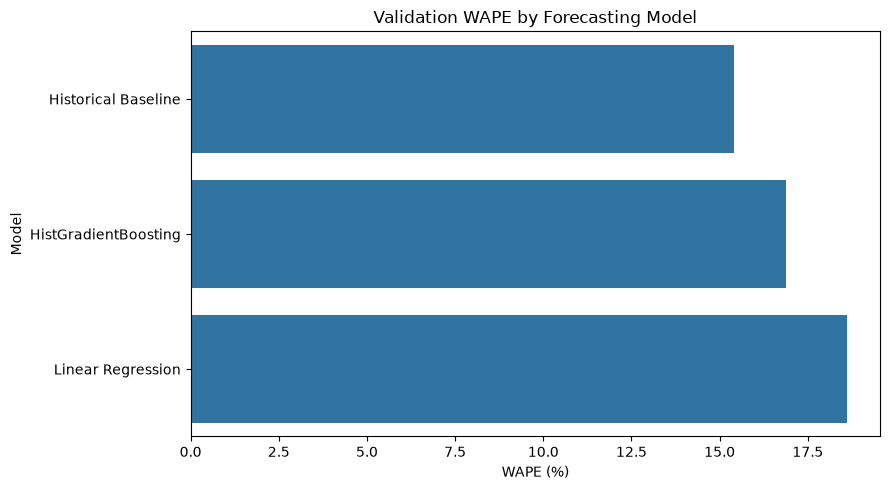

In [79]:
best_model_name = df_validation_evaluation.loc[0, 'model']
best_validation_wape = df_validation_evaluation.loc[0, 'WAPE (%)']

print(f'Selected model : {best_model_name}')
print(f'Validation WAPE: {best_validation_wape:.2f}%')

plt.figure(figsize=(9, 5))
sns.barplot(data=df_validation_evaluation, x='WAPE (%)', y='model')
plt.title('Validation WAPE by Forecasting Model')
plt.xlabel('WAPE (%)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## b. Final test evaluation

In [81]:
lookup_columns = ['LocationID', 'hour_of_day', 'day_of_week', 'completed_trips']

df_train_validation = pd.concat(
    [df_train[lookup_columns], df_validation[lookup_columns]],
    ignore_index=True
)

df_final_baseline_lookup = (
    df_train_validation
    .groupby(['LocationID', 'hour_of_day', 'day_of_week'], as_index=False)
    .agg(forecast_prediction=('completed_trips', 'mean'))
)

print(f'Train-validation rows: {len(df_train_validation):,}')
print(f'Final lookup rows     : {len(df_final_baseline_lookup):,}')

del df_train_validation

Train-validation rows: 2,106,480
Final lookup rows     : 44,016


In [82]:
df_test_predictions = df_test.merge(
    df_final_baseline_lookup,
    on=['LocationID', 'hour_of_day', 'day_of_week'],
    how='left'
)

test_actual = df_test_predictions['completed_trips'].to_numpy()
test_prediction = df_test_predictions['forecast_prediction'].to_numpy()

df_test_evaluation = pd.DataFrame({
    'model': [best_model_name],
    'WAPE (%)': [calculate_wape(test_actual, test_prediction)],
    'MAE': [mean_absolute_error(test_actual, test_prediction)],
    'MAPE nonzero (%)': [calculate_mape_nonzero(test_actual, test_prediction)],
    'Bias (%)': [calculate_bias(test_actual, test_prediction)]
})

df_test_evaluation.round(2)

,model,WAPE (%),MAE,MAPE nonzero (%),Bias (%)
0,Historical Baseline,20.22,21.85,28.64,-4.81


In [83]:
final_test_passed = (
    len(df_test_predictions) == len(df_test)
    and len(df_final_baseline_lookup) == 44016
    and df_test_predictions['forecast_prediction'].isna().sum() == 0
    and (df_test_predictions['forecast_prediction'] < 0).sum() == 0
)

print(f'Test prediction rows : {len(df_test_predictions):,}')
print(f'Missing predictions  : {df_test_predictions["forecast_prediction"].isna().sum():,}')
print(f'Negative predictions : {(df_test_predictions["forecast_prediction"] < 0).sum():,}')

Test prediction rows : 194,928
Missing predictions  : 0
Negative predictions : 0


## c. Test error analysis

In [93]:
df_test_error = df_test_predictions.copy()
df_test_error['absolute_error'] = abs(df_test_error['completed_trips'] - df_test_error['forecast_prediction'])
df_test_error['signed_error'] = df_test_error['forecast_prediction'] - df_test_error['completed_trips']

df_daily_test_error = (
    df_test_error.groupby('demand_date', as_index=False)
    .agg(
        actual_trips=('completed_trips', 'sum'),
        predicted_trips=('forecast_prediction', 'sum'),
        absolute_error=('absolute_error', 'sum'),
        signed_error=('signed_error', 'sum')
    )
)

df_daily_test_error['WAPE (%)'] = df_daily_test_error['absolute_error'] / df_daily_test_error['actual_trips'] * 100
df_daily_test_error['Bias (%)'] = df_daily_test_error['signed_error'] / df_daily_test_error['actual_trips'] * 100

df_daily_test_error.sort_values(
    'WAPE (%)',
    ascending=False
).head(10).round({
    'predicted_trips': 2,
    'absolute_error': 2,
    'signed_error': 2,
    'WAPE (%)': 2,
    'Bias (%)': 2
})

,demand_date,actual_trips,predicted_trips,absolute_error,signed_error,WAPE (%),Bias (%)
24,2024-12-25,506645,621546.33,297207.46,114901.33,58.66,22.68
30,2024-12-31,700066,583564.38,303775.33,-116501.62,43.39,-16.64
25,2024-12-26,493447,655983.02,200449.02,162536.02,40.62,32.94
23,2024-12-24,616897,583564.38,213581.08,-33332.62,34.62,-5.40
26,2024-12-27,556671,715964.35,182776.52,159293.35,32.83,28.62
27,2024-12-28,619891,767556.02,188155.23,147665.02,30.35,23.82
28,2024-12-29,545334,659573.77,147019.09,114239.77,26.96,20.95
22,2024-12-23,608648,558561.88,134091.96,-50086.12,22.03,-8.23
29,2024-12-30,523025,558561.88,105034.92,35536.88,20.08,6.79
10,2024-12-11,741695,621546.33,144649.79,-120148.67,19.50,-16.20


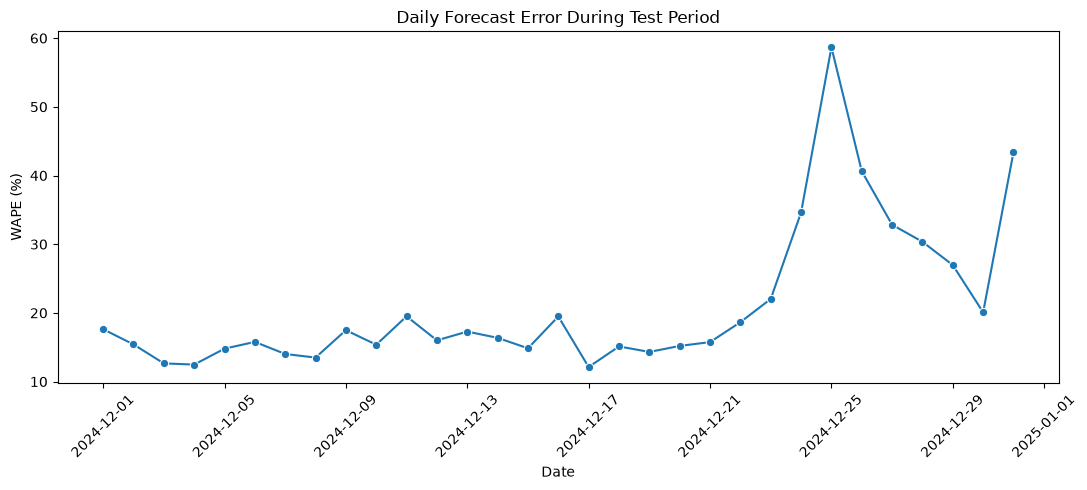

In [89]:
plt.figure(figsize=(11, 5))
sns.lineplot(data=df_daily_test_error, x='demand_date', y='WAPE (%)', marker='o')
plt.title('Daily Forecast Error During Test Period')
plt.xlabel('Date')
plt.ylabel('WAPE (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
df_zone_volume = (
    pd.concat([
        df_train[['LocationID', 'completed_trips']],
        df_validation[['LocationID', 'completed_trips']]
    ])
    .groupby('LocationID', as_index=False)
    .agg(avg_hourly_trips=('completed_trips', 'mean'))
)

df_zone_volume['volume_tier'] = pd.qcut(
    df_zone_volume['avg_hourly_trips'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df_test_tier = df_test_predictions.merge(
    df_zone_volume[['LocationID', 'volume_tier']],
    on='LocationID',
    how='left'
)

tier_results = []

for tier in ['Low', 'Medium', 'High']:
    tier_data = df_test_tier[df_test_tier['volume_tier'] == tier]
    actual = tier_data['completed_trips'].to_numpy()
    prediction = tier_data['forecast_prediction'].to_numpy()

    tier_results.append({
        'volume_tier': tier,
        'WAPE (%)': calculate_wape(actual, prediction),
        'MAE': mean_absolute_error(actual, prediction),
        'Bias (%)': calculate_bias(actual, prediction)
    })

df_test_tier_evaluation = pd.DataFrame(tier_results)
df_test_tier_evaluation.round(2)

,volume_tier,WAPE (%),MAE,Bias (%)
0,Low,23.65,5.78,-8.40
1,Medium,18.50,16.33,-7.53
2,High,20.53,43.62,-3.26


# 8. Generate Future Forecast

In [96]:
if best_model_name != 'Historical Baseline':
    raise ValueError('Future forecast code currently expects Historical Baseline.')

df_production_lookup = (
    df_hourly_demand
    .groupby(['LocationID', 'hour_of_day', 'day_of_week'], as_index=False)
    .agg(forecast_completed_trips=('completed_trips', 'mean'))
)

print(f'Production lookup rows: {len(df_production_lookup):,}')

Production lookup rows: 44,016


In [97]:
future_start = pd.Timestamp('2025-01-01')
future_end = pd.Timestamp('2025-01-08')

df_future_time = pd.DataFrame({
    'time_id': pd.date_range(
        start=future_start,
        end=future_end,
        freq='h',
        inclusive='left'
    )
})

df_forecast_zones = (
    df_hourly_demand[
        ['LocationID', 'pickup_zone', 'pickup_borough']
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

df_future_forecast = df_future_time.merge(df_forecast_zones, how='cross')
df_future_forecast['forecast_date'] = df_future_forecast['time_id'].dt.normalize()
df_future_forecast['hour_of_day'] = df_future_forecast['time_id'].dt.hour
df_future_forecast['day_of_week'] = df_future_forecast['time_id'].dt.dayofweek + 1
df_future_forecast['is_weekend'] = df_future_forecast['day_of_week'].isin([6, 7]).astype('int8')

In [98]:
df_future_forecast = df_future_forecast.merge(
    df_production_lookup,
    on=['LocationID', 'hour_of_day', 'day_of_week'],
    how='left'
)

df_future_forecast = df_future_forecast.merge(
    df_zone_volume[['LocationID', 'volume_tier']],
    on='LocationID',
    how='left'
)

df_future_forecast['model'] = best_model_name

df_future_forecast[
    [
        'time_id',
        'LocationID',
        'pickup_zone',
        'pickup_borough',
        'forecast_completed_trips',
        'volume_tier'
    ]
].head()

,time_id,LocationID,pickup_zone,pickup_borough,forecast_completed_trips,volume_tier
0,2025-01-01,2,Jamaica Bay,Queens,0.000000,Low
1,2025-01-01,3,Allerton/Pelham Gardens,Bronx,24.423077,Medium
2,2025-01-01,4,Alphabet City,Manhattan,58.653846,Medium
3,2025-01-01,5,Arden Heights,Staten Island,2.153846,Low
4,2025-01-01,6,Arrochar/Fort Wadsworth,Staten Island,5.673077,Low


In [99]:
expected_forecast_rows = 7 * 24 * actionable_zones

forecast_passed = (
    len(df_future_forecast) == expected_forecast_rows
    and df_future_forecast['time_id'].nunique() == 168
    and df_future_forecast['LocationID'].nunique() == 262
    and df_future_forecast['forecast_completed_trips'].isna().sum() == 0
    and (df_future_forecast['forecast_completed_trips'] < 0).sum() == 0
)

print(f'Expected forecast rows: {expected_forecast_rows:,}')
print(f'Actual forecast rows  : {len(df_future_forecast):,}')
print(f'Unique forecast hours : {df_future_forecast["time_id"].nunique():,}')
print(f'Missing predictions   : {df_future_forecast["forecast_completed_trips"].isna().sum():,}')

Expected forecast rows: 44,016
Actual forecast rows  : 44,016
Unique forecast hours : 168
Missing predictions   : 0


In [100]:
df_future_daily = (
    df_future_forecast
    .groupby('forecast_date', as_index=False)
    .agg(forecast_completed_trips=('forecast_completed_trips', 'sum'))
)

df_future_daily.round({'forecast_completed_trips': 2})

,forecast_date,forecast_completed_trips
0,2025-01-01,624003.85
1,2025-01-02,657569.17
2,2025-01-03,718829.48
3,2025-01-04,769328.79
4,2025-01-05,659669.06
5,2025-01-06,562954.66
6,2025-01-07,589658.06


# 9. Save Forecast Output

In [101]:
df_forecast_output = df_future_forecast.rename(
    columns={'time_id': 'forecast_time'}
).copy()

df_forecast_output['pickup_zone'] = df_forecast_output['pickup_zone'].astype(str)
df_forecast_output['pickup_borough'] = df_forecast_output['pickup_borough'].astype(str)
df_forecast_output['volume_tier'] = df_forecast_output['volume_tier'].astype(str)

df_validation_metrics = df_validation_evaluation.copy()
df_validation_metrics.insert(0, 'evaluation_period', 'Validation')

df_test_metrics = df_test_evaluation.copy()
df_test_metrics.insert(0, 'evaluation_period', 'Test')

df_model_evaluation = pd.concat(
    [df_validation_metrics, df_test_metrics],
    ignore_index=True
)

print(f'Forecast output rows : {len(df_forecast_output):,}')
print(f'Model evaluation rows: {len(df_model_evaluation):,}')
print(f'Tier evaluation rows : {len(df_test_tier_evaluation):,}')

Forecast output rows : 44,016
Model evaluation rows: 4
Tier evaluation rows : 3


In [102]:
con.close()
con_write = duckdb.connect(str(database_path))

con_write.execute("""
    CREATE OR REPLACE TABLE forecast_output AS
    SELECT * FROM df_forecast_output
""")

con_write.execute("""
    CREATE OR REPLACE TABLE forecast_model_evaluation AS
    SELECT * FROM df_model_evaluation
""")

con_write.execute("""
    CREATE OR REPLACE TABLE forecast_test_tier_evaluation AS
    SELECT * FROM df_test_tier_evaluation
""")

print('Forecast outputs saved.')

Forecast outputs saved.


# 10. Final Validation and Close Connection

In [103]:
df_saved_forecast_check = con_write.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT forecast_time) AS unique_hours,
        COUNT(DISTINCT LocationID) AS unique_zones,
        MIN(forecast_time) AS min_forecast_time,
        MAX(forecast_time) AS max_forecast_time,
        COUNT(*) FILTER (
            WHERE forecast_completed_trips IS NULL
        ) AS missing_predictions,
        COUNT(*) FILTER (
            WHERE forecast_completed_trips < 0
        ) AS negative_predictions,
        COUNT(DISTINCT model) AS number_of_models
    FROM forecast_output
""").df()

df_saved_forecast_check

,total_rows,unique_hours,unique_zones,min_forecast_time,max_forecast_time,missing_predictions,negative_predictions,number_of_models
0,44016,168,262,2025-01-01,2025-01-07 23:00:00,0,0,1


In [104]:
saved_evaluation_rows = con_write.execute("""
    SELECT COUNT(*) FROM forecast_model_evaluation
""").fetchone()[0]

saved_tier_rows = con_write.execute("""
    SELECT COUNT(*) FROM forecast_test_tier_evaluation
""").fetchone()[0]

saved_model = con_write.execute("""
    SELECT DISTINCT model FROM forecast_output
""").fetchone()[0]

print(f'Model evaluation rows: {saved_evaluation_rows:,}')
print(f'Tier evaluation rows : {saved_tier_rows:,}')
print(f'Forecast model       : {saved_model}')

Model evaluation rows: 4
Tier evaluation rows : 3
Forecast model       : Historical Baseline


In [105]:
saved_check = df_saved_forecast_check.iloc[0]

notebook_passed = (
    saved_check['total_rows'] == 44016
    and saved_check['unique_hours'] == 168
    and saved_check['unique_zones'] == 262
    and saved_check['min_forecast_time'] == pd.Timestamp('2025-01-01 00:00:00')
    and saved_check['max_forecast_time'] == pd.Timestamp('2025-01-07 23:00:00')
    and saved_check['missing_predictions'] == 0
    and saved_check['negative_predictions'] == 0
    and saved_check['number_of_models'] == 1
    and saved_evaluation_rows == 4
    and saved_tier_rows == 3
    and saved_model == best_model_name
)

con_write.close()

NOTEBOOK 05: PASSED
Database connection closed.
